In [25]:
import pandas as pd
from ax.service.ax_client import AxClient, ObjectiveProperties
import matplotlib.pyplot as plt


from ax.modelbridge.factory import Models
from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy


def virtual_exp(r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12):

    complexity = sum(1 for x in [r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12] if x != 0)
    cost = r1+r2+r3+r4+r5+r6+r7+r8+r9+r10+r11+r12
    performance = 0.3*r1*(1+r2) - 0.5*r3*r4 + r5**2 + 0.8*r9 - r10*r11 + 0.2*r12
    return {'complexity': complexity, 'cost': cost, 'performance': performance}


# generation strategy
gs = GenerationStrategy(
    steps=[
        GenerationStep(
            model=Models.SOBOL,
            num_trials=8,  # how many sobol trials to perform (rule of thumb: 2 * number of params)
            model_kwargs={"seed": 0},
        ),
        GenerationStep(
            model=Models.SAASBO,
            num_trials=-1,
            model_kwargs={},
        ),
    ]
)

# initialize the AxClient
ax_client = AxClient(generation_strategy=gs)

# create the design space and objective space
ax_client.create_experiment(
    parameters=[

        {"name": "r1", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r2", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r3", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r4", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r5", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r6", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r7", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r8", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r9", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r10", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r11", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "r12", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"}],


    objectives={
        'complexity': ObjectiveProperties(minimize=True, threshold=5),
        'cost': ObjectiveProperties(minimize=True, threshold=0.5),
        'performance': ObjectiveProperties(minimize=False),
    },


    parameter_constraints=[
#        "c1 + c2 + c3 + c4 + c5 + c6 + c7 + c8 + c9 + c10 + c11 + c12 <= 8.0",  # example of a sum constraint, which may be redundant/unintended if composition_constraint is also selected
#        "r1 + r2 + r3 + r4 + r5 + r6 + r7 + r8 + r9 + r10 + r11 + r12 <= 1.0",  # example of a sum constraint, which may be redundant/unintended if composition_constraint is also selected
    ],
)


batch_size = 1

for i in range(30):

    parameterizations, optimization_complete = ax_client.get_next_trials(batch_size)
    for trial_index, parameterization in list(parameterizations.items()):
        # extract parameters

        r1 = parameterization["r1"]
        r2 = parameterization["r2"]
        r3 = parameterization["r3"]
        r4 = parameterization["r4"]
        r5 = parameterization["r5"]
        r6 = parameterization["r6"]
        r7 = parameterization["r7"]
        r8 = parameterization["r8"]
        r9 = parameterization["r9"]
        r10 = parameterization["r10"]
        r11 = parameterization["r11"]
        r12 = parameterization["r12"]

        results = virtual_exp(r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12)
        ax_client.complete_trial(trial_index=trial_index, raw_data=results)
        


                

[INFO 04-28 12:18:05] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 04-28 12:18:05] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='r1', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r2', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r3', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r4', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r5', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r6', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r7', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r8', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r9', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='r10', parameter_type=FLOAT, range=[0.0, 1.0]), RangeP

In [26]:
objectives = ax_client.objective_names
df = ax_client.get_trials_data_frame()
pareto_results = ax_client.get_pareto_optimal_parameters()

In [27]:
df

,trial_index,arm_name,trial_status,generation_method,generation_node,complexity,cost,performance,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12
0,0,0_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.732985,1.244802,0.475107,0.592524,0.494479,0.313852,0.956092,0.083302,0.098763,0.347466,0.846915,0.761508,0.882807,0.880169
1,1,1_0,COMPLETED,Sobol,GenerationStep_0,12.0,5.684614,0.462721,0.861477,0.166011,0.504516,0.570255,0.086635,0.600777,0.807654,0.809979,0.369148,0.372135,0.183181,0.352846
2,2,2_0,COMPLETED,Sobol,GenerationStep_0,12.0,4.383001,0.459535,0.530153,0.888269,0.161508,0.108681,0.271814,0.796786,0.367982,0.515712,0.060535,0.000032,0.453061,0.228468
3,3,3_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.141397,0.200648,0.135028,0.369958,0.839498,0.853366,0.654210,0.278900,0.538070,0.076857,0.535900,0.616034,0.737804,0.505771
4,4,4_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.233772,0.141257,0.004971,0.848399,0.744539,0.991378,0.576699,0.184836,0.469659,0.718018,0.222328,0.476403,0.298922,0.697620
5,5,5_0,COMPLETED,Sobol,GenerationStep_0,12.0,5.610461,0.579276,0.642287,0.394053,0.254575,0.236059,0.442586,0.639873,0.686301,0.126850,0.744713,0.891663,0.514119,0.037383
6,6,6_0,COMPLETED,Sobol,GenerationStep_0,12.0,7.995660,0.392425,0.997517,0.679604,0.911449,0.711928,0.136558,0.945191,0.247178,0.418551,0.934970,0.730555,0.869178,0.412980
7,7,7_0,COMPLETED,Sobol,GenerationStep_0,12.0,5.564132,1.137508,0.353339,0.063150,0.089439,0.468327,0.750406,0.489865,0.909393,0.986563,0.410488,0.151182,0.068741,0.823239
8,8,8_0,COMPLETED,SAASBO,GenerationStep_1,2.0,2.000000,1.300000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,9,9_0,COMPLETED,SAASBO,GenerationStep_1,3.0,3.000000,1.300000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


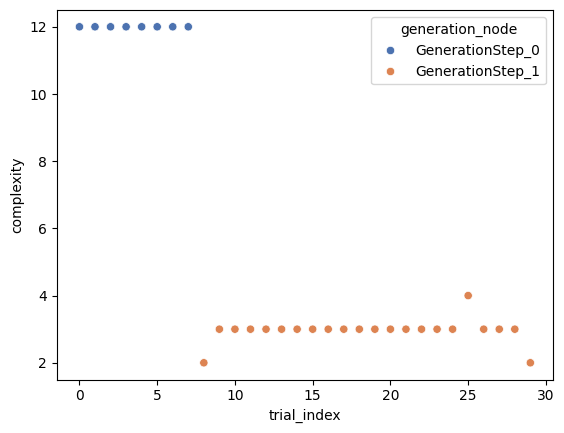

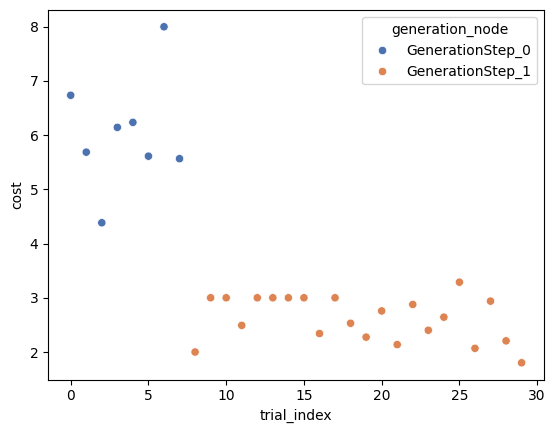

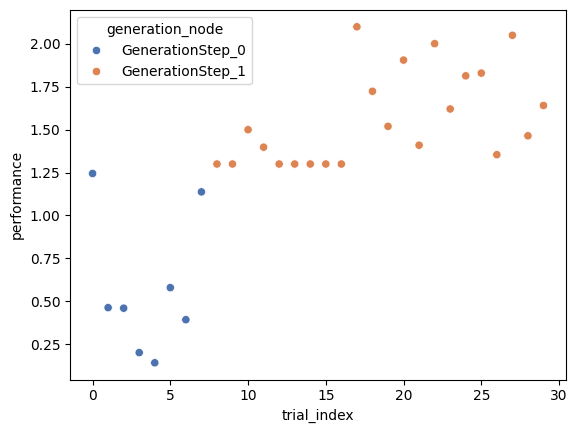

In [28]:
import seaborn as sns

for col in objectives:
    fig = plt.figure()
    sns.scatterplot(data=df, x='trial_index', y=col, hue='generation_node', palette='deep')

In [30]:
ax_client.get_pareto_optimal_parameters()

OrderedDict()

In [39]:
ax_client.get_contour_plot(metric_name = 'cost')

[INFO 04-28 14:25:45] ax.service.ax_client: Retrieving contour plot with parameter 'r1' on X-axis and 'r2' on Y-axis, for metric 'cost'. Remaining parameters are affixed to the middle of their range.


AxPlotConfig(data={'data': [{'autocolorscale': False, 'autocontour': True, 'colorbar': {'tickfont': {'size': 8}, 'ticksuffix': '', 'x': 0.45, 'y': 0.5}, 'colorscale': [[0.0, 'rgb(247,252,253)'], [0.125, 'rgb(229,245,249)'], [0.25, 'rgb(204,236,230)'], [0.375, 'rgb(153,216,201)'], [0.5, 'rgb(102,194,164)'], [0.625, 'rgb(65,174,118)'], [0.75, 'rgb(35,139,69)'], [0.875, 'rgb(0,109,44)'], [1.0, 'rgb(0,68,27)']], 'contours': {'coloring': 'heatmap'}, 'hoverinfo': 'x+y+z', 'ncontours': 25, 'x': [0.0, 0.02040816326530612, 0.04081632653061224, 0.061224489795918366, 0.08163265306122448, 0.1020408163265306, 0.12244897959183673, 0.14285714285714285, 0.16326530612244897, 0.18367346938775508, 0.2040816326530612, 0.22448979591836732, 0.24489795918367346, 0.26530612244897955, 0.2857142857142857, 0.3061224489795918, 0.32653061224489793, 0.3469387755102041, 0.36734693877551017, 0.3877551020408163, 0.4081632653061224, 0.42857142857142855, 0.44897959183673464, 0.4693877551020408, 0.4897959183673469, 0.510

In [37]:
ax_client.get_contour_plot?

Signature:
ax_client.get_contour_plot(
    param_x: str | None = None,
    param_y: str | None = None,
    metric_name: str | None = None,
) -> ax.plot.base.AxPlotConfig
Docstring:
Retrieves a plot configuration for a contour plot of the response
surface. For response surfaces with more than two parameters,
selected two parameters will appear on the axes, and remaining parameters
will be affixed to the middle of their range. If contour params arguments
are not provided, the first two parameters in the search space will be
used. If contour metrics are not provided, objective will be used.

Args:
    param_x: name of parameters to use on x-axis for
        the contour response surface plots.
    param_y: name of parameters to use on y-axis for
        the contour response surface plots.
    metric_name: Name of the metric, for which to plot the response
        surface.
File:      ~/opt/anaconda3/envs/sdlnano_plot/lib/python3.11/site-packages/ax/service/ax_client.py
Type:      method